In [1]:
import os, sys
from pathlib import Path
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import importlib

import torch
from torch.utils.data import DataLoader

import torch.nn as nn #?
from torch.functional import F #?
import torch.distributions as dist #?
from torch.utils.data import DataLoader, TensorDataset, random_split #?
import torchvision #?

import zuko

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor, TQDMProgressBar

sys.path.append('../')
from utils import datasets
import utils.resnet_cond as resnet
import utils.lightning_flows as LFlows
from utils import lightning_flows_density as LFlowsDensity


/n/home11/aakhmetzhanova/.conda/envs/ccl-env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: aakhmetzhanova. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /n/home11/aakhmetzhanova/.netrc
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or runnin

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Main code

In [3]:
field      = 'Mgas'
home_dir   = Path("/n/netscratch/dvorkin_lab/Lab/aakhmetzhanova/evidence-estimation-Astrid/") 
save_dir   = home_dir / f"trained_models/Maps_{field}/"


In [5]:
# Load summarizer.
npe_k_cond = False
n_params   = 6
summary_dim = 40

checkpoint = save_dir / f"summarizer_scale_cond_{field}_Astrid/"
checkpoint = checkpoint / "k_conv_lr_1e-4/checkpoints/best_val_loss.ckpt"
summarizer    = LFlows.LightningFlowCond.load_from_checkpoint(checkpoint, 
                                                           device=device,
                                                           k_cond='conv',
                                                           npe_k_cond=npe_k_cond,
                                                           summary_dim=summary_dim, n_params=n_params,
                                                           model_name='resnet10t.c3_in1k',).summarizer
summarizer.eval();

# Load density estimator for the summaries.
checkpoint        = save_dir / "density_summarizer_cond_Mgas_Astrid/k_context_1_lr_5e-3/".format(field)
checkpoint        = checkpoint / "checkpoints/best_val_loss.ckpt"
density_estimator = LFlowsDensity.LightningFlowDensity.load_from_checkpoint(checkpoint, 
                                                                            summarizer=summarizer, 
                                                                            summary_dim=summary_dim, 
                                                                            cond=True, 
                                                                            context=1).density_est
density_estimator.eval();


In [6]:
# Load CV maps for all sets.
minimum = np.array([0.1, 0.6, 0.25, 0.25, 0.5, 0.5])[:n_params] 
maximum = np.array([0.5, 1.0, 4.00, 4.00, 2.0, 2.0])[:n_params] 

splits    = 15
grid      = 256

set_name = 'CV' 

params_A   = np.loadtxt(home_dir / f'data/params_{set_name}_Astrid.txt',)[:, :n_params]
params_A  = (params_A - (minimum+maximum)/2)/((maximum - minimum)/2)   # rescale parameters
params_A  = np.repeat(params_A[:, None, :], splits, axis = 1) # reshape the parameters to match the shape of the maps

params_S  = np.loadtxt(home_dir / f'data/params_{set_name}_SIMBA.txt',)[:, :n_params] 
params_S  = (params_S - (minimum+maximum)/2)/((maximum - minimum)/2)   # rescale parameters
params_S  = np.repeat(params_S[:, None, :], splits, axis = 1) # reshape the parameters to match the shape of the maps

params_I   = np.loadtxt(home_dir / f'data/params_{set_name}_IllustrisTNG.txt',)[:, :n_params] 
params_I  = (params_I - (minimum+maximum)/2)/((maximum - minimum)/2)   # rescale parameters
params_I  = np.repeat(params_I[:, None, :], splits, axis = 1) # reshape the parameters to match the shape of the maps


dset_size = params_A.shape[0]
maps_A    = np.load(home_dir / f'data/2D/Maps_{field}_Astrid_{set_name}_z=0.00.npy').reshape(dset_size, -1, 1, grid, grid)[:, :splits] 
maps_S    = np.load(home_dir / f'data/2D/Maps_{field}_SIMBA_{set_name}_z=0.00.npy').reshape(dset_size, -1, 1, grid, grid)[:, :splits]
maps_I    = np.load(home_dir / f'data/2D/Maps_{field}_IllustrisTNG_{set_name}_z=0.00.npy').reshape(dset_size, -1, 1, grid, grid)[:, :splits] 

# Normalization constants
maps    = np.load(home_dir  / f'data/2D/Maps_{field}_Astrid_LH_z=0.00.npy').reshape(1000, -1, 1, grid, grid)[:, :splits]
maps_mean, maps_std = np.log10(maps).mean(), np.log10(maps).std()


In [7]:
# Smoothing scales
k_min, k_max   = 2., 45
k_smooth_array = np.logspace(np.log10(k_min), np.log10(k_max), num=10)


batch_size   = 100
seed         = 1
train_frac, valid_frac, test_frac = 0., 0., 1. # We evaluate log evidence on CV set as a whole.


In [8]:
# Compute evidence for Astrid
logE_A = []
for i, k_smooth in enumerate(k_smooth_array):
    logE_k = []
    _, _, dset = datasets.create_datasets_maps(
        maps_A, params_A, 
        train_frac, valid_frac, test_frac, 
        seed=seed, rotations=False,
        smoothing=True, k_smooth=k_smooth,
        k_min=k_min, k_max=k_max,
        normalize_k=True,
        linear=False, log_scale=True, 
        standardize=True, 
        maps_mean=maps_mean, maps_std=maps_std,
    )
    
    dataloader  = DataLoader(dset, batch_size, shuffle = False, )
    for maps, params, k in dataloader:
        with torch.no_grad():
            maps = maps.float().to(device=device)
            k    = k.float().to(device=device)
            
            summaries      = summarizer([maps, k])
            logE = density_estimator(k).log_prob(summaries).cpu().numpy()
            logE_k.append(logE)
    logE_A.append(np.concatenate(logE_k))
logE_A = np.array(logE_A)

# Compute evidence for SIMBA
logE_S = []
for i, k_smooth in enumerate(k_smooth_array):
    logE_k = []
    _, _, dset = datasets.create_datasets_maps(maps_S, params_S, 
                                                   train_frac, valid_frac, test_frac, 
                                                   seed=seed, rotations=False, 
                                                   smoothing=True, k_smooth=k_smooth,
                                                   k_min=k_min, k_max=k_max,
                                                   normalize_k=True,
                                                   linear=False, log_scale=True, 
                                                   standardize=True, 
                                                   maps_mean=maps_mean, maps_std=maps_std,)
    dataloader  = DataLoader(dset, batch_size, shuffle = False, )
    for maps, params, k in dataloader:
        with torch.no_grad():
            maps = maps.float().to(device=device)
            k    = k.float().to(device=device)
            
            summaries      = summarizer([maps, k])
            logE = density_estimator(k).log_prob(summaries).cpu().numpy()
            logE_k.append(logE)
    logE_S.append(np.concatenate(logE_k))
logE_S = np.array(logE_S)


# Compute evidence for IllustrisTNG
logE_I = []
for i, k_smooth in enumerate(k_smooth_array):
    logE_k = []
    _, _, dset = datasets.create_datasets_maps(maps_I, params_I, 
                                                   train_frac, valid_frac, test_frac, 
                                                   seed=seed, rotations=False, 
                                                   smoothing=True, k_smooth=k_smooth,
                                                   k_min=k_min, k_max=k_max+1e-2,
                                                   normalize_k=True,
                                                   linear=False, log_scale=True, 
                                                   standardize=True, 
                                                   maps_mean=maps_mean, maps_std=maps_std,)
    dataloader  = DataLoader(dset, batch_size, shuffle = False, )
    for maps, params, k in dataloader:
        with torch.no_grad():
            maps = maps.float().to(device=device)
            k    = k.float().to(device=device)
            
            summaries      = summarizer([maps, k])
            logE = density_estimator(k).log_prob(summaries).cpu().numpy()
            logE_k.append(logE)
    logE_I.append(np.concatenate(logE_k))
logE_I = np.array(logE_I)

# Save results for plotting.
results_dir = Path("results/")
np.save(results_dir / '{:s}_log_evidence_SIMBA_CV.npy'.format(field), logE_S)
np.save(results_dir / '{:s}_log_evidence_Astrid_CV.npy'.format(field), logE_A)
np.save(results_dir / '{:s}_log_evidence_IllustrisTNG_CV.npy'.format(field), logE_I)

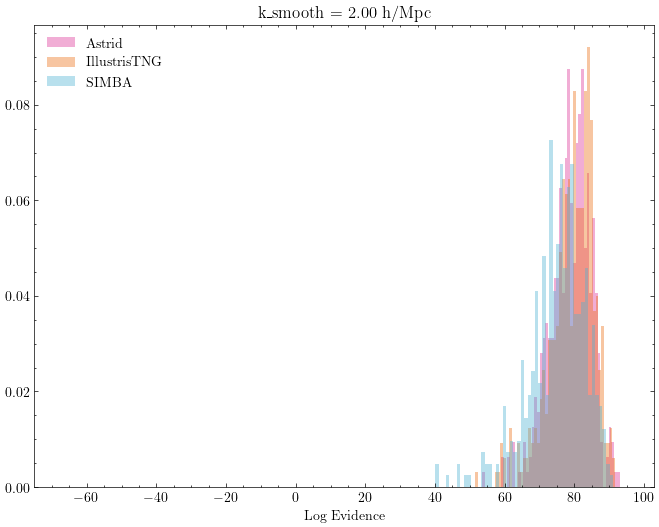

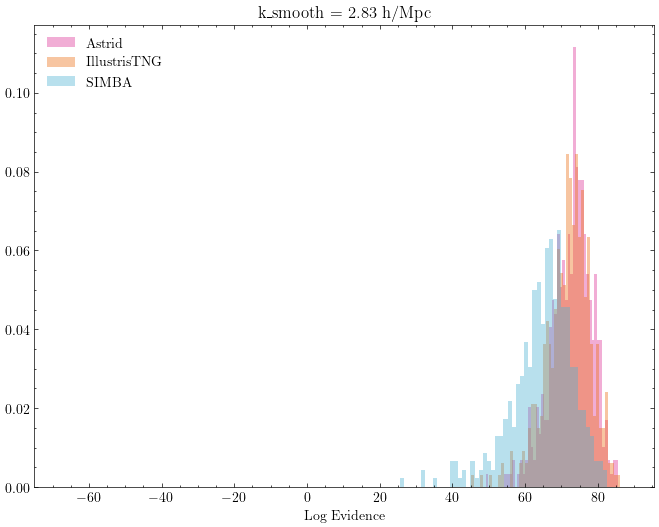

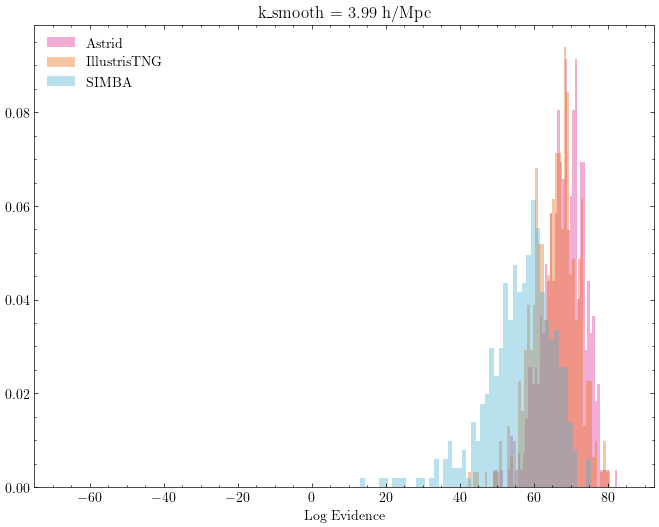

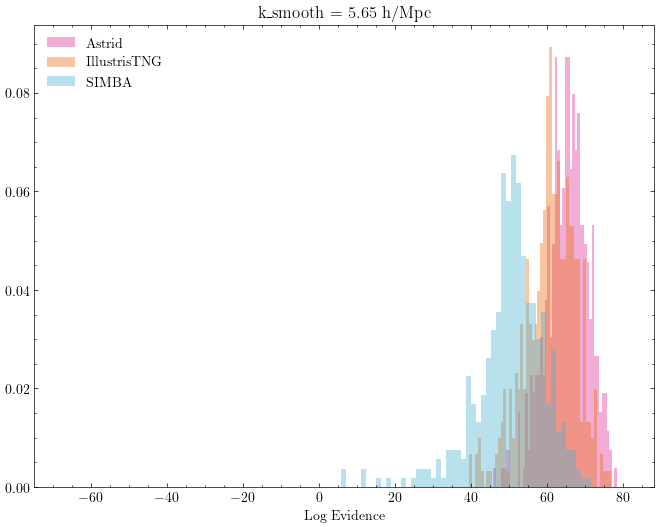

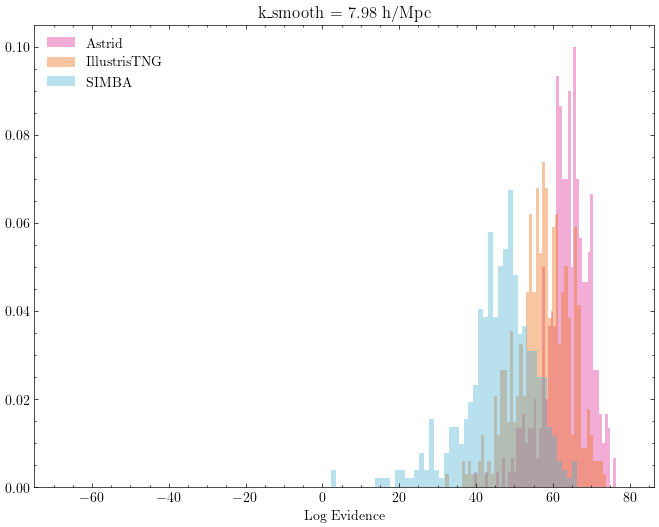

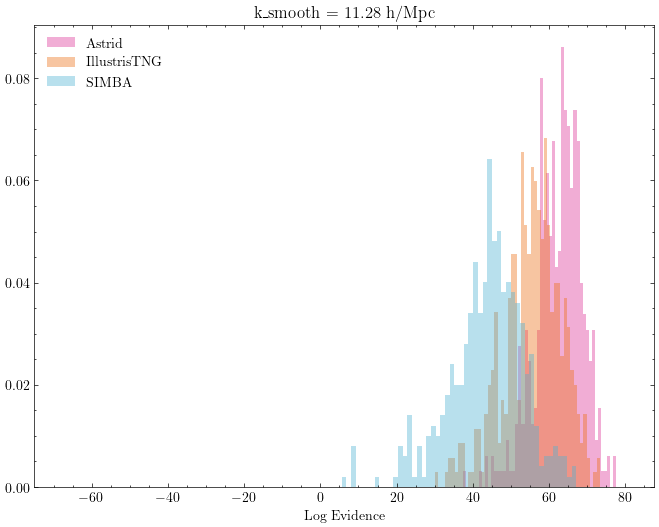

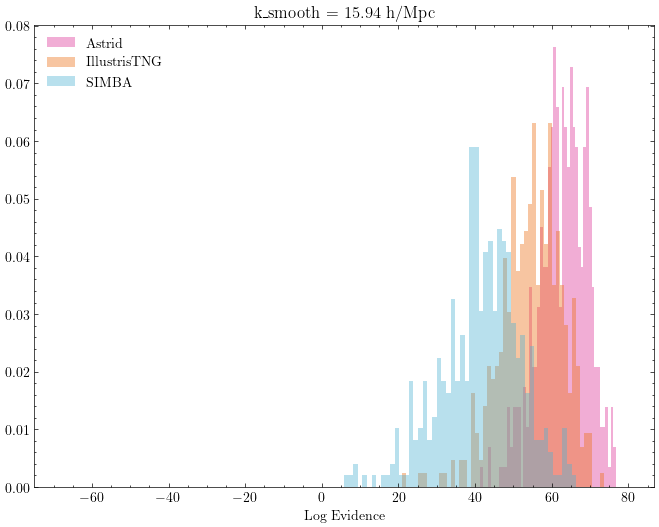

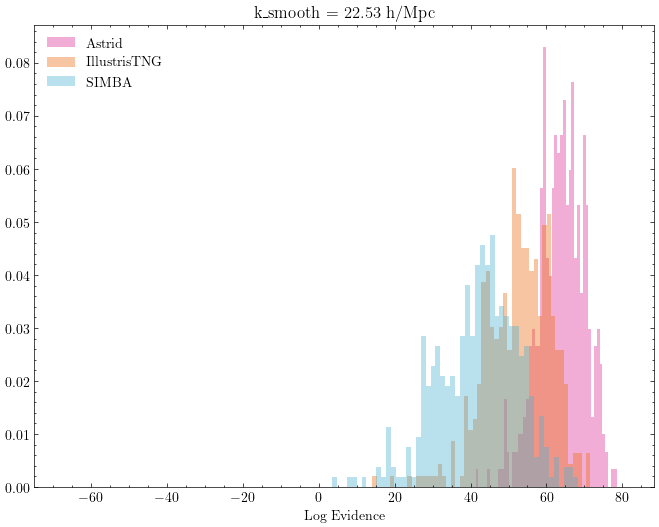

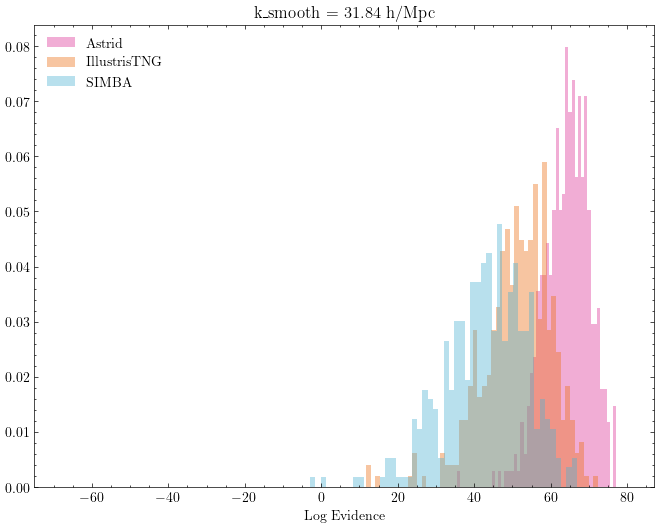

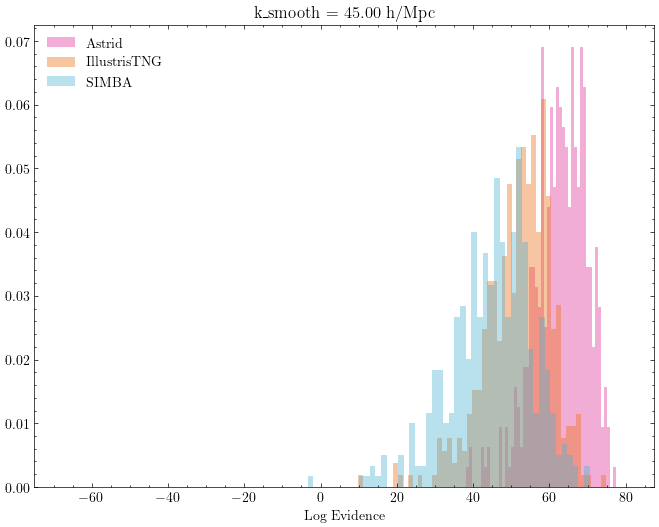

In [9]:
# Visualize distribution of log-evidence values for different smoothing scales.

plt.style.use(['science'])

alpha = 0.4
n_bins  = 50
density = True

colors = ['#dd3497', '#ec7014', '#4eb3d3', ]#['palevioletred', 'chocolate', 'steelblue']

for i in range(len(k_smooth_array)):
    k_smooth = k_smooth_array[i]
    plt.figure(i, figsize=(8, 6))
    plt.title(f'k_smooth = {k_smooth:.2f} h/Mpc')
    plt.xlabel('Log Evidence')
    plt.xlim(-75, logE_A[i].max() + 10)
    counts, bins, _ = plt.hist(logE_A[i], bins=n_bins, alpha = alpha, density = density, 
             label='Astrid', color=colors[0])
    plt.hist(logE_I[i], bins=n_bins, alpha = alpha, density = density, 
             label='IllustrisTNG', color=colors[1])
    plt.hist(logE_S[i], bins=n_bins, alpha = alpha, density = density, 
             label='SIMBA', color=colors[2])
    plt.legend(loc='best')
    

## Compute log evidence for the summaries of the test part of the LH set.

In [10]:
# load all LH maps
minimum = np.array([0.1, 0.6, 0.25, 0.25, 0.5, 0.5])[:n_params] 
maximum = np.array([0.5, 1.0, 4.00, 4.00, 2.0, 2.0])[:n_params] 

splits    = 15
grid      = 256

set_name = 'LH' 

params_A   = np.loadtxt(home_dir / f'data/params_{set_name}_Astrid.txt',)[:, :n_params]
params_A  = (params_A - (minimum+maximum)/2)/((maximum - minimum)/2)   # rescale parameters
params_A  = np.repeat(params_A[:, None, :], splits, axis = 1) # reshape the parameters to match the shape of the maps

params_S  = np.loadtxt(home_dir / f'data/params_{set_name}_SIMBA.txt',)[:, :n_params] 
params_S  = (params_S - (minimum+maximum)/2)/((maximum - minimum)/2)   # rescale parameters
params_S  = np.repeat(params_S[:, None, :], splits, axis = 1) # reshape the parameters to match the shape of the maps

params_I   = np.loadtxt(home_dir / f'data/params_{set_name}_IllustrisTNG.txt',)[:, :n_params] 
params_I  = (params_I - (minimum+maximum)/2)/((maximum - minimum)/2)   # rescale parameters
params_I  = np.repeat(params_I[:, None, :], splits, axis = 1) # reshape the parameters to match the shape of the maps


dset_size = params_A.shape[0]
maps_A    = np.load(home_dir / f'data/2D/Maps_{field}_Astrid_{set_name}_z=0.00.npy').reshape(dset_size, -1, 1, grid, grid)[:, :splits] 
maps_S    = np.load(home_dir / f'data/2D/Maps_{field}_SIMBA_{set_name}_z=0.00.npy').reshape(dset_size, -1, 1, grid, grid)[:, :splits]
maps_I    = np.load(home_dir / f'data/2D/Maps_{field}_IllustrisTNG_{set_name}_z=0.00.npy').reshape(dset_size, -1, 1, grid, grid)[:, :splits] 



In [11]:
batch_size = 100
seed       = 1
train_frac, valid_frac, test_frac = 0.9, 0.05, 0.05

# Compute evidence for Astrid.
logE_A = []
for i, k_smooth in enumerate(k_smooth_array):
    logE_k = []
    _, _, dset = datasets.create_datasets_maps(maps_A, params_A, 
                                                   train_frac, valid_frac, test_frac, 
                                                   seed=seed, rotations=False, 
                                                   smoothing=True, k_smooth=k_smooth,
                                                   k_min=k_min, k_max=k_max,
                                                   normalize_k=True,
                                                   linear=False, log_scale=True, 
                                                   standardize=True, 
                                                   maps_mean=maps_mean, maps_std=maps_std,)
    dataloader  = DataLoader(dset, batch_size, shuffle = False, )
    for maps, params, k in dataloader:
        with torch.no_grad():
            maps = maps.float().to(device=device)
            k    = k.float().to(device=device)
            
            summaries      = summarizer([maps, k])
            logE = density_estimator(k).log_prob(summaries).cpu().numpy()
            logE_k.append(logE)
    logE_A.append(np.concatenate(logE_k))
logE_A = np.array(logE_A)

# Compute evidence for IllustrisTNG
logE_I = []
for i, k_smooth in enumerate(k_smooth_array):
    logE_k = []
    _, _, dset = datasets.create_datasets_maps(maps_I, params_I, 
                                                   train_frac, valid_frac, test_frac, 
                                                   seed=seed, rotations=False, 
                                                   smoothing=True, k_smooth=k_smooth,
                                                   k_min=k_min, k_max=k_max,
                                                   normalize_k=True,
                                                   linear=False, log_scale=True, 
                                                   standardize=True, 
                                                   maps_mean=maps_mean, maps_std=maps_std,)
    dataloader  = DataLoader(dset, batch_size, shuffle = False, )
    for maps, params, k in dataloader:
        with torch.no_grad():
            maps = maps.float().to(device=device)
            k    = k.float().to(device=device)
            
            summaries      = summarizer([maps, k])
            logE = density_estimator(k).log_prob(summaries).cpu().numpy()
            logE_k.append(logE)
    logE_I.append(np.concatenate(logE_k))
logE_I = np.array(logE_I)


# Compute evidence for SIMBA.
logE_S = []
for i, k_smooth in enumerate(k_smooth_array):
    logE_k = []
    _, _, dset = datasets.create_datasets_maps(maps_S, params_S, 
                                                   train_frac, valid_frac, test_frac, 
                                                   seed=seed, rotations=False, 
                                                   smoothing=True, k_smooth=k_smooth,
                                                   k_min=k_min, k_max=k_max,
                                                   normalize_k=True,
                                                   linear=False, log_scale=True, 
                                                   standardize=True, 
                                                   maps_mean=maps_mean, maps_std=maps_std,)
    dataloader  = DataLoader(dset, batch_size, shuffle = False, )
    for maps, params, k in dataloader:
        with torch.no_grad():
            maps = maps.float().to(device=device)
            k    = k.float().to(device=device)
            
            summaries      = summarizer([maps, k])
            logE = density_estimator(k).log_prob(summaries).cpu().numpy()
            logE_k.append(logE)
    logE_S.append(np.concatenate(logE_k))
logE_S = np.array(logE_S)

results_dir = Path("results/")
np.save(results_dir / '{:s}_log_evidence_SIMBA_LH_test.npy'.format(field), logE_S)
np.save(results_dir / '{:s}_log_evidence_Astrid_LH_test.npy'.format(field), logE_A)
np.save(results_dir / '{:s}_log_evidence_IllustrisTNG_LH_test.npy'.format(field), logE_I)

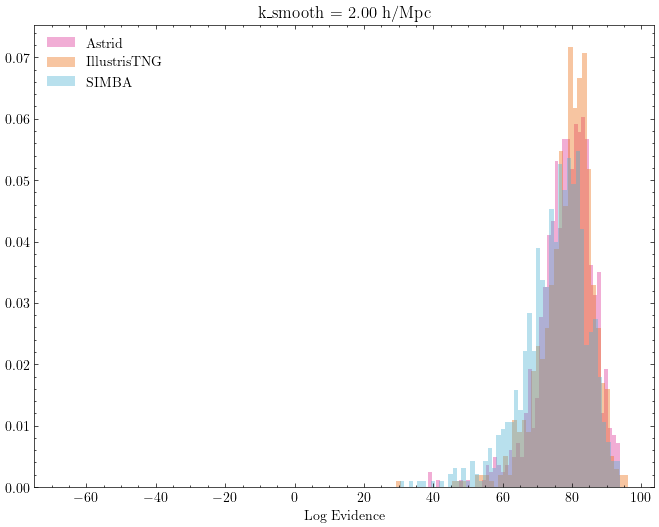

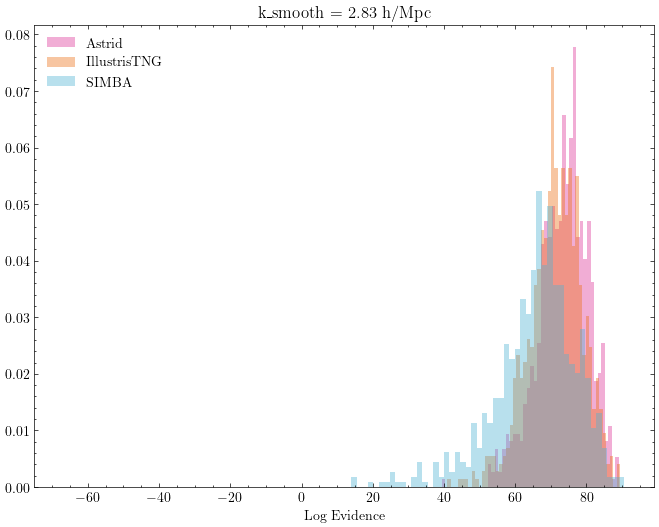

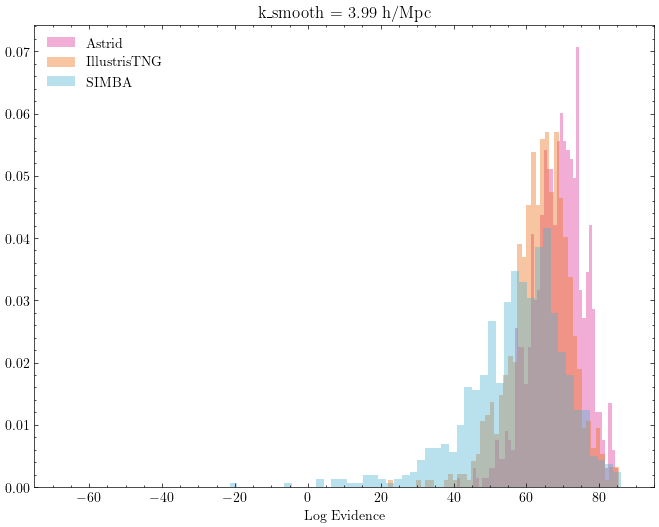

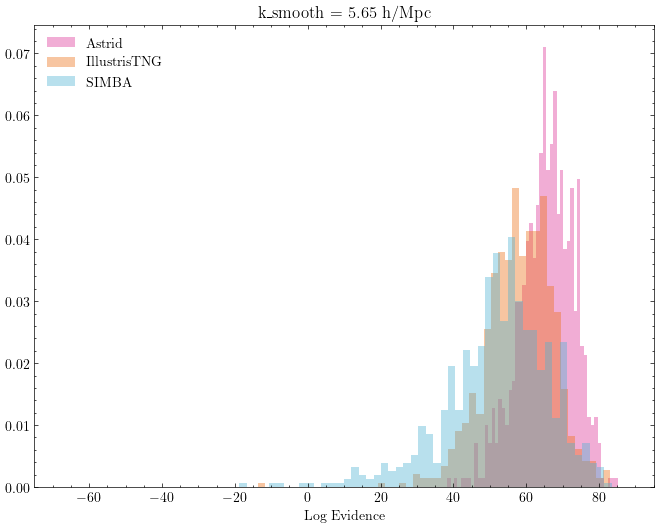

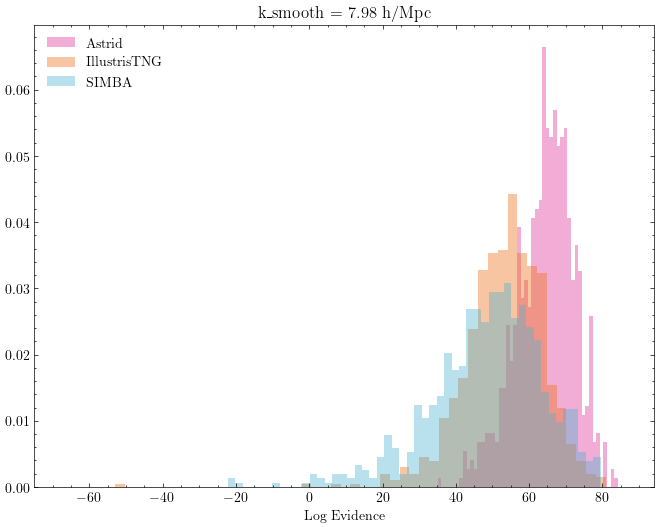

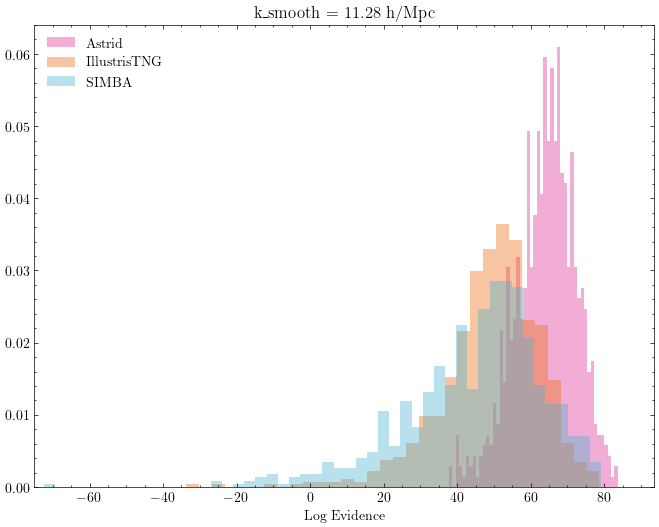

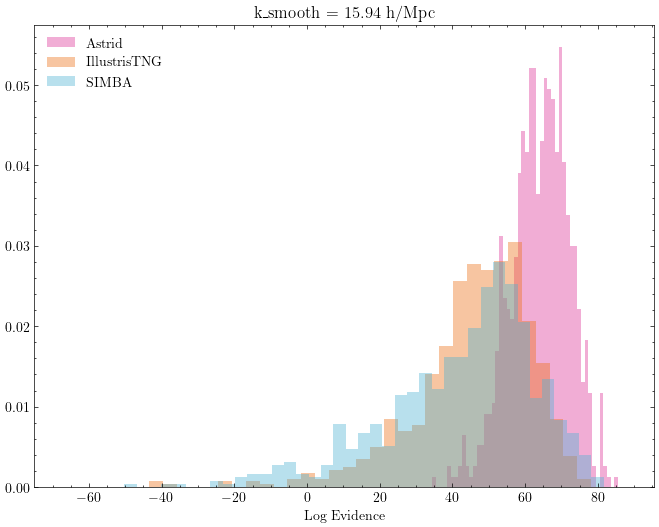

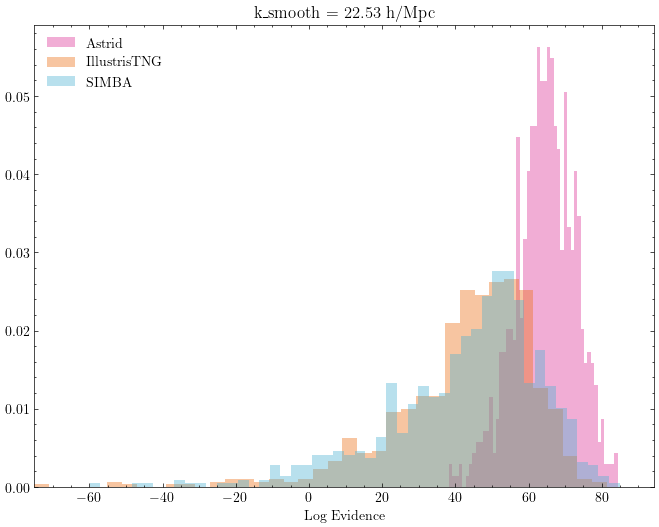

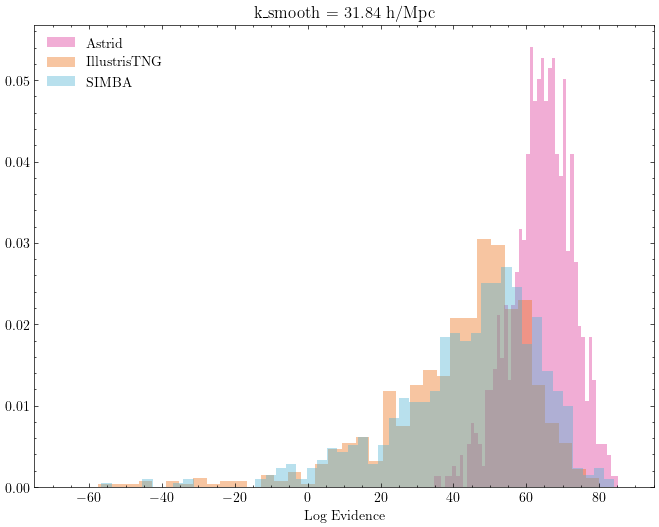

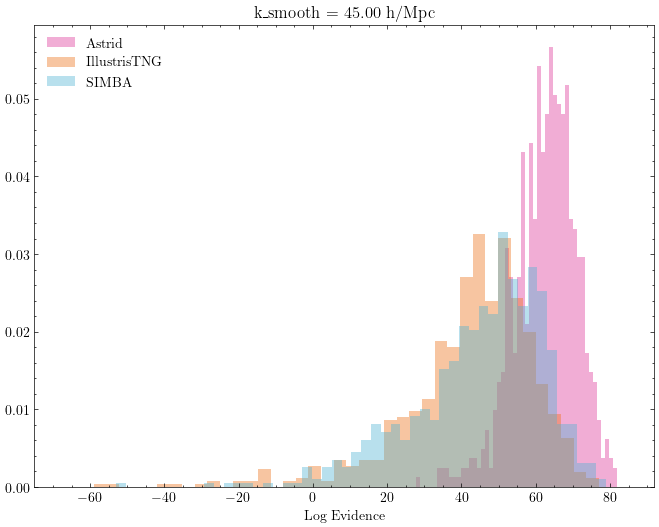

In [12]:
# Visualize distribution of log-evidence values for different smoothing scales.

plt.style.use(['science'])

alpha = 0.4
n_bins  = 50
density = True

colors = ['#dd3497', '#ec7014', '#4eb3d3', ]#['palevioletred', 'chocolate', 'steelblue']

for i in range(len(k_smooth_array)):
    k_smooth = k_smooth_array[i]
    plt.figure(i, figsize=(8, 6))
    plt.title(f'k_smooth = {k_smooth:.2f} h/Mpc')
    plt.xlabel('Log Evidence')
    plt.xlim(-75, logE_A[i].max() + 10)
    
    counts, bins, _ = plt.hist(logE_A[i], bins=n_bins, alpha = alpha, density = density, 
             label='Astrid', color=colors[0])
    plt.hist(logE_I[i], bins=n_bins, alpha = alpha, density = density, 
             label='IllustrisTNG', color=colors[1])
    plt.hist(logE_S[i], bins=n_bins, alpha = alpha, density = density, 
             label='SIMBA', color=colors[2])
    plt.legend(loc='best')
    